# Cleared for Launch: AI Governance Assessment
## ClinicalCompanion — MedAssist AI

**Course:** Data Governance for Generative AI (cd13873)

---

### Scenario

You are an **AI Governance Analyst at MedAssist AI**, preparing **ClinicalCompanion** — a generative AI clinical decision support system — for EU market launch within 3 months. Your manager needs a governance assessment before the board meeting next week.

### Your Deliverables

You will produce **two files** that together cover all six governance deliverables:

| # | Deliverable | Notebook (code + analysis) | Workbook (written analysis) |
|---|---|---|---|
| 1 | EU AI Act Classification | Compliance gap analysis | Classification reasoning + gap table |
| 2 | Risk Register + Heatmap | **Risk heatmap visualization** | Risk details + mitigations |
| 3 | Vendor Evaluation | Vendor scorecard visualization | Evaluation narrative + recommendation |
| 4 | Model Card | Disaggregated performance chart | Model Card content |
| 5 | Monitoring & Incident Response | Monitoring dashboard | KPI definitions + incident plan |
| 6 | Executive Summary | Executive readiness dashboard | Board-ready narrative |

### Project Structure

```
starter/
├── data/                          ← Input datasets (provided — do not modify)
│   ├── system_spec.json           ← ClinicalCompanion system specification
│   ├── training_data_summary.csv  ← Training data sources
│   ├── performance_metrics.csv    ← Model performance by subgroup
│   ├── risk_register.csv          ← Risk register (NIST AI RMF)
│   ├── vendor_assessment.csv      ← Vendor evaluation criteria + scores
│   ├── vendor_profile.json        ← Vendor company profile
│   ├── eu_ai_act_requirements.csv ← EU AI Act compliance requirements
│   ├── monitoring_kpis.csv        ← Monitoring KPI definitions
│   ├── incident_types.csv         ← Incident taxonomy
│   └── severity_levels.csv        ← Incident severity definitions
├── results/                       ← Your outputs will be saved here
├── governance_assessment.ipynb    ← THIS NOTEBOOK (code deliverable)
└── governance_workbook.xlsx       ← Written deliverable (fill in the 6 sheets)
```

### How to Work Through This Notebook

1. Read each step's instructions carefully
2. Look for **🔧 TODO** markers — these are where you write code
3. Run your code and verify the outputs make sense
4. Save all visualizations to `results/`
5. Use insights from your analysis to fill in `governance_workbook.xlsx`

**Estimated time: ~3.5 hours** (notebook) + **~1.5 hours** (workbook) = **5 hours total**

---
## Step 0: Environment Setup

Run this cell to set up your environment. **No changes needed here.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
from pathlib import Path

# Paths
DATA_DIR = Path('data')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

# Display settings
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("Environment ready.")
print(f"Data directory:    {DATA_DIR.resolve()}")
print(f"Results directory:  {RESULTS_DIR.resolve()}")

Environment ready.
Data directory:    /Users/thaismedeiros/Curso-Udacity/project-02/starter/data
Results directory:  /Users/thaismedeiros/Curso-Udacity/project-02/starter/results


---
## Step 1: Load and Explore the ClinicalCompanion System Specification

**Time estimate: ~20 minutes**

Your first task as a governance analyst is to understand the system you're assessing. Load the system specification and training data summary, then extract the key facts that will inform your governance assessment.

**Key questions to answer:**
- What type of AI system is this? Who uses it?
- What foundation model powers it and how is it accessed?
- What data was it trained on and where does it come from?
- What is the deployment timeline and regulatory status?

### 1a. Load and display the system overview

🔧 **TODO:** Load `system_spec.json` and print a formatted overview of the system. Include at minimum:
- System name, version, type
- Foundation model name, parameters, access method
- Cloud region and security (encryption)
- Target launch date

*Hint: Use `json.load()` to read the file, then access nested keys like `spec['system']['name']`*

In [2]:
# Step 1a: Load and display system overview

# Load the system specification JSON
with open(DATA_DIR / 'system_spec.json') as f:
    spec = json.load(f)

# Print a formatted header
print("=" * 70)
print("CLINICALCOMPANION v1.0 — SYSTEM OVERVIEW")
print("=" * 70)

# 🔧 TODO: Create a dictionary of key system facts by accessing nested keys in `spec`.
# Extract at minimum: System name+version, Type, Developer, Foundation Model name,
# Parameters, Access Method, Cloud Region, Encryption, Target Launch Date.
# The JSON has nested structure — explore keys like 'system', 'architecture', etc.

overview = {
    "System": f"{spec['system']['name']} v{spec['system']['version']}",
    "Type": spec["system"]["type"],
    "Developer": spec["system"]["developer"],
    "Foundation Model": spec["architecture"]["foundation_model"]["model_name"],
    "Parameters": spec["architecture"]["foundation_model"]["parameters"],
    "Access Method": spec["architecture"]["foundation_model"]["access_method"],
    "Cloud Region": spec["architecture"]["infrastructure"]["region"],
    "Encryption": (
        f"{spec['architecture']['infrastructure']['encryption_at_rest']} at rest; "
        f"{spec['architecture']['infrastructure']['encryption_in_transit']} in transit"
    ),
    "Target Launch Date": spec["system"]["release_date_planned"],
}

# 🔧 TODO: Loop through the overview dict and print each fact in a formatted way.

for key, value in overview.items():
    print(f"{key}: {value}")


CLINICALCOMPANION v1.0 — SYSTEM OVERVIEW
System: ClinicalCompanion v1.0
Type: Clinical Decision Support System (CDSS)
Developer: MedAssist AI
Foundation Model: FoundationHealth Medical LLM v3.2
Parameters: 7B
Access Method: API
Cloud Region: eu-west-1 (Frankfurt)
Encryption: AES-256 at rest; TLS 1.3 in transit
Target Launch Date: 2025-09-01


### 1b. Display intended users and out-of-scope uses

🔧 **TODO:** From the system spec, print:
1. The list of **intended users** (who is allowed to use this system?)
2. The list of **out-of-scope uses** (what is this system NOT for?)

*Think about: Why do these matter for governance? How do they affect risk classification?*

In [3]:
# Step 1b: Print intended users and out-of-scope uses

print("INTENDED USERS:")
# 🔧 TODO: Loop through the intended users list in the spec and print each one with a bullet point.
for user in spec["intended_use"]["intended_users"]:
    print("•", user)

print("\nOUT-OF-SCOPE USES:")
# 🔧 TODO: Loop through the out-of-scope uses list in the spec and print each one.

for use in spec["intended_use"]["out_of_scope"]:
    print("•", use)


INTENDED USERS:
• Licensed physicians (primary care and specialists)
• Clinical fellows and residents (under attending supervision)
• Nurse practitioners and physician assistants (where authorized)

OUT-OF-SCOPE USES:
• Autonomous diagnosis or treatment decisions
• Standalone diagnostic tool (must not replace physician judgment)
• Patient-facing interface (no direct patient use)
• Pediatric populations (under 18) in initial release
• Emergency triage as sole decision-making tool


### 1c. Load and explore training data sources

🔧 **TODO:** Load `training_data_summary.csv` and display:
1. A table of all training data sources with their record counts and geography
2. The total number of training records

*Think about: What geographic gaps do you see? How might this affect fairness?*

In [4]:
# Step 1c: Load and display training data summary

training_df = pd.read_csv(DATA_DIR / 'training_data_summary.csv')

print("=" * 70)
print("TRAINING DATA SOURCES")
print("=" * 70)

# 🔧 TODO: Display a table showing the source_name, record_count, geography, and data_type columns.
# Hint: Select the relevant columns and use a pandas method to display without the index.
print(
    training_df[
        ["source_name", "record_count", "geography", "data_type"]
    ].to_string(index=False)
)


# 🔧 TODO: Print the total number of training records, formatted with commas for readability.
print(training_df["record_count"].sum())

TRAINING DATA SOURCES
                    source_name  record_count                    geography                    data_type
Partner Hospital Network A (EU)        280000 Germany, France, Netherlands               EHR encounters
Partner Hospital Network B (US)        170000  United States (multi-state)               EHR encounters
         PubMed Abstract Corpus       2100000                       Global Medical literature abstracts
            Expert Clinical Q&A         12000                       EU, US            Curated Q&A pairs
   Clinical Practice Guidelines           340                  EU, US, WHO          Practice guidelines
2562340


---
## Step 2: EU AI Act Risk Classification

**Time estimate: ~45 minutes**

This is one of the most important governance tasks. You need to walk through the EU AI Act's classification framework and determine ClinicalCompanion's risk level. Then analyze compliance gaps.

**EU AI Act Classification Decision Tree:**
1. **Article 5 — Prohibited practices?** (social scoring, exploitation, subliminal manipulation, real-time biometric ID)
2. **Article 6(1) — Safety component under EU harmonisation legislation?** (check if it falls under MDR, machinery, toys, etc.)
3. **Annex III — High-risk use cases?** (biometric ID, critical infrastructure, education, employment, essential services, law enforcement, migration, justice)
4. If none of the above → Limited risk or minimal risk

### 2a. Prohibited practices check

🔧 **TODO:** For each prohibited practice under Article 5, evaluate whether ClinicalCompanion engages in it. Print a clear pass/fail for each one with a brief justification.

*The four prohibited categories are: social scoring, exploiting vulnerabilities, real-time remote biometric identification, and subliminal manipulation.*

In [5]:
# Step 2a: Evaluate Article 5 prohibited practices

print("STEP 1: Prohibited Practices Check (Article 5)")
print("-" * 50)

# The four prohibited categories to check against
prohibited_practices = [
    "Social scoring by public authorities",
    "Exploiting vulnerabilities",
    "Real-time remote biometric identification",
    "Subliminal manipulation"
]

# 🔧 TODO: For each prohibited practice, evaluate whether ClinicalCompanion engages in it.
# Print a clear pass/fail with justification. Consider what the system does (clinical
# decision support) and whether any practice applies.
evaluations = {
    "Social scoring by public authorities": (
        False,
        "Not identified in the provided system specification. "
        "The documented purpose is patient-specific clinical decision support, "
        "not the evaluation or ranking of individuals based on social behavior."
    ),
    "Exploiting vulnerabilities": (
        False,
        "Not identified in the provided system specification. "
        "No functionality intended to manipulate or exploit individuals based "
        "on age, disability, or socioeconomic vulnerability is documented."
    ),
    "Real-time remote biometric identification": (
        False,
        "Not identified in the provided architecture. The system processes "
        "patient records through EHR and HL7 FHIR integrations, and no remote "
        "biometric identification functionality is documented."
    ),
    "Subliminal manipulation": (
        False,
        "Not identified in the provided intended-use description. Outputs are "
        "presented explicitly to physicians as diagnostic suggestions, confidence "
        "scores, reasoning, and safety flags."
    )
}

for practice in prohibited_practices:
    engages_in_practice, justification = evaluations[practice]

    if engages_in_practice:
        status = "❌ FAIL"
    else:
        status = "✅ PASS"

    print(f"{status} — {practice}")
    print(f"   Justification: {justification}\n")

# 🔧 TODO: Print the conclusion — does the system pass the Article 5 check?

# Verify if at least one prohibited practice was identified
article_5_violation = any(
    evaluations[practice][0]
    for practice in prohibited_practices
)

print("-" * 50)
if article_5_violation:
    print(
        "ARTICLE 5 CONCLUSION: FAIL — ClinicalCompanion engages "
        "in at least one prohibited AI practice."
    )
else:
    print(
        "ARTICLE 5 CONCLUSION: PASS — No prohibited practices "
        "were identified for ClinicalCompanion."
    )


STEP 1: Prohibited Practices Check (Article 5)
--------------------------------------------------
✅ PASS — Social scoring by public authorities
   Justification: Not identified in the provided system specification. The documented purpose is patient-specific clinical decision support, not the evaluation or ranking of individuals based on social behavior.

✅ PASS — Exploiting vulnerabilities
   Justification: Not identified in the provided system specification. No functionality intended to manipulate or exploit individuals based on age, disability, or socioeconomic vulnerability is documented.

✅ PASS — Real-time remote biometric identification
   Justification: Not identified in the provided architecture. The system processes patient records through EHR and HL7 FHIR integrations, and no remote biometric identification functionality is documented.

✅ PASS — Subliminal manipulation
   Justification: Not identified in the provided intended-use description. Outputs are presented explicitly 

### 2b. High-risk classification

🔧 **TODO:** Determine whether ClinicalCompanion qualifies as HIGH-RISK. Consider:

1. **Is it a safety component under EU harmonisation legislation?** (Article 6(1))
   - Is ClinicalCompanion a medical device under MDR 2017/745?
   - If yes, what MDR class would it be? (Class I, IIa, IIb, or III?)

2. **Does it fall under Annex III high-risk use cases?**

Print your classification with the legal basis (which Article and Annex).

*Hint: A clinical decision support system that assists physicians with diagnoses falls under medical device regulation.*

In [6]:
# Step 2b: Walk through the high-risk classification decision tree

print("STEP 2: Safety Component Under EU Harmonisation Legislation?")
print("-" * 50)

# 🔧 TODO: Answer these questions using what you know about ClinicalCompanion:
# 1. Is it a medical device under MDR 2017/745? (Consider: it assists physicians with diagnoses)
# 2. If yes, what MDR class? (Class I, IIa, IIb, or III — consider the risk level)
# 3. Does it require a conformity assessment?
# Print your answers with justification.

is_medical_device = True
mdr_class = "Class IIa"
requires_third_party_conformity = True

print(f"Medical device under MDR 2017/745: "
      f"{'YES' if is_medical_device else 'NO'}")

print(
    "Justification: ClinicalCompanion analyzes patient records and provides "
    "patient-specific diagnostic and treatment suggestions used by physicians. "
    "Therefore, it has an intended medical purpose and is treated as medical "
    "device software under MDR 2017/745."
)

print(f"\nWorking MDR classification: {mdr_class}")

print(
    "Justification: Under MDR Annex VIII, Rule 11, software that provides "
    "information used to make diagnostic or therapeutic decisions is generally "
    "classified as Class IIa. A higher class may apply if an incorrect decision "
    "could cause serious deterioration, irreversible harm, or death."
)

print(
    "\nThird-party conformity assessment required: "
    f"{'YES' if requires_third_party_conformity else 'NO'}"
)

print(
    "Justification: A Class IIa medical device normally requires conformity "
    "assessment involving a Notified Body before EU market placement."
)


print("\nSTEP 3: Annex III High-Risk Use Cases?")
print("-" * 50)
# 🔧 TODO: Check if the system falls under any Annex III category.
# The 8 categories are: biometric ID, critical infrastructure, education, employment,
# essential services, law enforcement, migration, justice.
annex_iii_assessment = {
    "Biometric identification": False,
    "Critical infrastructure": False,
    "Education and vocational training": False,
    "Employment and worker management": False,
    "Access to essential services": False,
    "Law enforcement": False,
    "Migration, asylum, and border control": False,
    "Administration of justice and democratic processes": False
}

for category, applies in annex_iii_assessment.items():
    status = "MATCH" if applies else "NO MATCH"
    print(f"{status:<8} — {category}")

annex_iii_match = any(annex_iii_assessment.values())

print(
    "\nAnnex III conclusion: "
    + (
        "The system matches an Annex III category."
        if annex_iii_match
        else "No direct Annex III category was identified."
    )
)

print(
    "Clinical decision support in healthcare is not, by itself, one of the "
    "eight Annex III use cases listed in this exercise. The system reaches "
    "the high-risk classification through Article 6(1), because it is medical "
    "device software covered by MDR 2017/745 and requires third-party "
    "conformity assessment."
)


# Final EU AI Act classification
article_6_1_high_risk = (
    is_medical_device
    and requires_third_party_conformity
)

if article_6_1_high_risk:
    final_classification = "HIGH-RISK AI SYSTEM"
    legal_basis = (
        "EU AI Act Article 6(1), Annex I, Section A, "
        "and MDR 2017/745"
    )
elif annex_iii_match:
    final_classification = "HIGH-RISK AI SYSTEM"
    legal_basis = "EU AI Act Article 6(2) and Annex III"
else:
    final_classification = "NOT CLASSIFIED AS HIGH-RISK"
    legal_basis = "No Article 6(1) or Annex III trigger identified"


# 🔧 TODO: Print the FINAL CLASSIFICATION with legal basis (which Article and Annex).
print("\n" + "=" * 70)
# Print your final classification here
print(f"FINAL CLASSIFICATION: {final_classification}")
print(f"LEGAL BASIS: {legal_basis}")
print("=" * 70)


STEP 2: Safety Component Under EU Harmonisation Legislation?
--------------------------------------------------
Medical device under MDR 2017/745: YES
Justification: ClinicalCompanion analyzes patient records and provides patient-specific diagnostic and treatment suggestions used by physicians. Therefore, it has an intended medical purpose and is treated as medical device software under MDR 2017/745.

Working MDR classification: Class IIa
Justification: Under MDR Annex VIII, Rule 11, software that provides information used to make diagnostic or therapeutic decisions is generally classified as Class IIa. A higher class may apply if an incorrect decision could cause serious deterioration, irreversible harm, or death.

Third-party conformity assessment required: YES
Justification: A Class IIa medical device normally requires conformity assessment involving a Notified Body before EU market placement.

STEP 3: Annex III High-Risk Use Cases?
--------------------------------------------------

### 2c. Compliance gap analysis

🔧 **TODO:** Load `eu_ai_act_requirements.csv` and analyze the compliance gaps:
1. Print each requirement with its current status and severity
2. Calculate and print a summary: how many Critical, High, Medium, Low gaps exist?

*Use emoji or symbols to make the status easy to scan (e.g., ✅ Compliant, ⚠️ Partial, 🔶 In Progress)*

*Think about: Which gaps are most urgent? What's the critical path to compliance?*

In [7]:
# Step 2c: Load and analyze EU AI Act compliance requirements

compliance_df = pd.read_csv(DATA_DIR / 'eu_ai_act_requirements.csv')

print("COMPLIANCE REQUIREMENTS (Articles 8-15):")
print("-" * 70)

# 🔧 TODO: Loop through each row of compliance_df and print:
#   - Article number, requirement name, current status, and severity
#   - Use emoji to make status easy to scan (e.g., ✅ Compliant, 🔶 In Progress, ⚠️ Partial)
# Relevant columns: 'article', 'requirement_name', 'current_status', 'severity'

# Symbol associated with each compliance status
status_symbols = {
    "Compliant": "✅",
    "In Progress": "🔶",
    "Partial": "⚠️",
    "Planned": "📅",
    "Not Started": "❌"
}

# Display every requirement
for _, row in compliance_df.iterrows():
    symbol = status_symbols.get(row["current_status"], "❓")

    print(
        f"{symbol} {row['article']} — {row['requirement_name']}\n"
        f"   Status: {row['current_status']} | "
        f"Severity: {row['severity']}"
    )

# 🔧 TODO: Print a gap summary showing how many Critical, High, Medium, Low gaps exist.
# Hint: Use value_counts() on the severity column.

# Count requirements by severity
severity_order = ["Critical", "High", "Medium", "Low"]

severity_counts = (
    compliance_df["severity"]
    .value_counts()
    .reindex(severity_order, fill_value=0)
)
print("\nGAP SUMMARY:")
print("-" * 70)

severity_symbols = {
    "Critical": "🔴",
    "High": "🟠",
    "Medium": "🟡",
    "Low": "🟢"
}

for severity in severity_order:
    print(
        f"{severity_symbols[severity]} "
        f"{severity}: {severity_counts[severity]}"
    )

# Identify the most urgent unresolved gaps
urgent_gaps = compliance_df[
    (compliance_df["current_status"] != "Compliant")
    & (compliance_df["severity"].isin(["Critical", "High"]))
]

print("\nMOST URGENT GAPS:")
print("-" * 70)

for _, row in urgent_gaps.iterrows():
    print(
        f"• {row['severity']} — {row['article']}: "
        f"{row['requirement_name']}\n"
        f"  Required action: {row['remediation_action']}\n"
        f"  Deadline: {row['deadline']} | Owner: {row['owner']}"
    )

COMPLIANCE REQUIREMENTS (Articles 8-15):
----------------------------------------------------------------------
⚠️ Article 9 — Risk Management System
   Status: Partial | Severity: High
🔶 Article 9 — Risk Identification
   Status: In Progress | Severity: Medium
❌ Article 9 — Residual Risk Evaluation
   Status: Not Started | Severity: High
⚠️ Article 10 — Data Governance
   Status: Partial | Severity: High
⚠️ Article 10 — Dataset Representativeness
   Status: Partial | Severity: High
🔶 Article 10 — Special Category Data
   Status: In Progress | Severity: Medium
🔶 Article 11 — Technical Documentation
   Status: In Progress | Severity: Medium
⚠️ Article 12 — Record-Keeping
   Status: Partial | Severity: Medium
📅 Article 12 — Log Retention
   Status: Planned | Severity: Medium
⚠️ Article 13 — Transparency
   Status: Partial | Severity: Medium
🔶 Article 13 — Instructions for Use
   Status: In Progress | Severity: Medium
✅ Article 14 — Human Oversight
   Status: Compliant | Severity: Low
✅ A

---
## Step 3: Risk Assessment (NIST AI RMF)

**Time estimate: ~30 minutes**

Load the risk register and analyze the 8 identified risks. The risks are organized by NIST AI RMF functions (Govern, Map, Measure, Manage).

**Key analysis tasks:**
- Load and display the risk register
- Calculate summary statistics (average score, max score, priority distribution)
- Identify which NIST functions have the most risk concentration
- Compare pre-mitigation vs. post-mitigation scores to assess effectiveness

### 3a. Load and summarize the risk register

🔧 **TODO:** Load `risk_register.csv` and display:
1. A summary table showing: risk_id, category, NIST function, likelihood, impact, risk score, priority
2. Key statistics: total risks, count by priority (Critical/High/Medium), average and max scores

*Hint: The risk_score column = likelihood × impact (5×5 scale, max 25)*

In [8]:
# Step 3a: Load risk register and display summary

risk_df = pd.read_csv(DATA_DIR / 'risk_register.csv')

print("=" * 70)
print("RISK REGISTER — ClinicalCompanion v1.0 (NIST AI RMF)")
print("=" * 70)

# 🔧 TODO: Display a summary table with these columns:
# risk_id, risk_category, nist_rmf_function, likelihood, impact, risk_score, priority
# Hint: Select columns and print as a table without the index.

summary_columns = [
    "risk_id",
    "risk_category",
    "nist_rmf_function",
    "likelihood",
    "impact",
    "risk_score",
    "priority"
]

# Select and display the requested columns
risk_summary = risk_df[summary_columns]

print(risk_summary.to_string(index=False))


# 🔧 TODO: Print key statistics:
# - Total number of risks
# - Count of Critical priority risks
# - Count of High priority risks
# - Average risk score (format to 1 decimal place)
# - Maximum risk score
print(f"\n{'─' * 40}")

# Count risks by priority
priority_counts = risk_df["priority"].value_counts()

total_risks = len(risk_df)
critical_count = priority_counts.get("Critical", 0)
high_count = priority_counts.get("High", 0)
medium_count = priority_counts.get("Medium", 0)

# Calculate score statistics
average_score = risk_df["risk_score"].mean()
maximum_score = risk_df["risk_score"].max()

print(f"\n{'─' * 40}")
print("KEY RISK STATISTICS")
print("─" * 40)

print(f"Total risks: {total_risks}")
print(f"Critical risks: {critical_count}")
print(f"High risks: {high_count}")
print(f"Medium risks: {medium_count}")
print(f"Average risk score: {average_score:.1f}")
print(f"Maximum risk score: {maximum_score}")

RISK REGISTER — ClinicalCompanion v1.0 (NIST AI RMF)
risk_id      risk_category nist_rmf_function  likelihood  impact  risk_score priority
  R-001          Technical           Measure           4       5          20 Critical
  R-002     Ethical / Bias               Map           4       4          16     High
  R-003 Legal / Regulatory            Govern           3       5          15     High
  R-004 Privacy / Security            Manage           3       5          15     High
  R-005        Operational            Manage           3       4          12     High
  R-006          Technical           Measure           3       4          12     High
  R-007   Ethical / Safety               Map           3       5          15     High
  R-008 Legal / Regulatory            Govern           3       5          15     High

────────────────────────────────────────

────────────────────────────────────────
KEY RISK STATISTICS
────────────────────────────────────────
Total risks: 8
Critical risk

### 3b. Analyze risk distribution by NIST AI RMF function

🔧 **TODO:** Group the risks by their `nist_rmf_function` and calculate:
- Number of risks per function
- Average risk score per function
- Which function carries the highest total risk?

*The four NIST AI RMF functions are: Govern, Map, Measure, Manage*

In [9]:
# Step 3b: Analyze risks by NIST AI RMF function

# The four NIST AI RMF functions: Govern, Map, Measure, Manage
# 🔧 TODO: Group the risk data by NIST RMF function and calculate for each:
# - Number of risks
# - Average risk score
# - Total risk score
# Hint: Use pandas groupby with named aggregation.

function_order = ["Govern", "Map", "Measure", "Manage"]

risk_by_function = (
    risk_df
    .groupby("nist_rmf_function")
    .agg(
        risk_count=("risk_id", "count"),
        average_risk_score=("risk_score", "mean"),
        total_risk_score=("risk_score", "sum")
    )
    .reindex(function_order)
    .reset_index()
)

print("RISK DISTRIBUTION BY NIST AI RMF FUNCTION")
print("-" * 70)

print(
    risk_by_function.to_string(
        index=False,
        formatters={
            "average_risk_score": "{:.1f}".format
        }
    )
)

# 🔧 TODO: Print which function carries the highest total risk.
highest_risk_row = risk_by_function.loc[
    risk_by_function["total_risk_score"].idxmax()
]

print("\n" + "─" * 40)
print(
    f"Function with highest total risk: "
    f"{highest_risk_row['nist_rmf_function']}"
)
print(
    f"Total risk score: "
    f"{highest_risk_row['total_risk_score']}"
)


RISK DISTRIBUTION BY NIST AI RMF FUNCTION
----------------------------------------------------------------------
nist_rmf_function  risk_count average_risk_score  total_risk_score
           Govern           2               15.0                30
              Map           2               15.5                31
          Measure           2               16.0                32
           Manage           2               13.5                27

────────────────────────────────────────
Function with highest total risk: Measure
Total risk score: 32


### 3c. Mitigation effectiveness analysis

🔧 **TODO:** Compare pre-mitigation scores vs. post-mitigation (residual) scores:
1. For each risk, calculate the percentage reduction
2. Print the total pre-mitigation score, total post-mitigation score, and overall reduction %
3. Which risk has the largest absolute reduction? Which has the smallest?

*This analysis will feed into the risk heatmap you'll create next.*

In [10]:
# Step 3c: Analyze mitigation effectiveness

# 🔧 TODO: For each risk, calculate the percentage reduction from pre- to post-mitigation.
# The columns you need are: 'risk_score' (pre) and 'residual_score' (post).
# Reduction % = (pre - post) / pre × 100

# Calculate the absolute reduction for each risk
risk_df["absolute_reduction"] = (
    risk_df["risk_score"] - risk_df["residual_score"]
)

# Calculate the percentage reduction for each risk
risk_df["reduction_pct"] = (
    risk_df["absolute_reduction"]
    / risk_df["risk_score"]
) * 100

# Display the results for each risk
mitigation_summary = risk_df[
    [
        "risk_id",
        "risk_score",
        "residual_score",
        "absolute_reduction",
        "reduction_pct"
    ]
]


# 🔧 TODO: Print the total pre-mitigation score, total post-mitigation score,
# and overall reduction percentage.
# Also identify: which risk has the largest reduction? Which has the smallest?

print("MITIGATION EFFECTIVENESS BY RISK")
print("-" * 70)

print(
    mitigation_summary.to_string(
        index=False,
        formatters={
            "reduction_pct": lambda value: f"{value:.1f}%"
        }
    )
)

# Calculate the overall totals
total_pre_mitigation = risk_df["risk_score"].sum()
total_post_mitigation = risk_df["residual_score"].sum()

total_absolute_reduction = (
    total_pre_mitigation - total_post_mitigation
)

overall_reduction_pct = (
    total_absolute_reduction / total_pre_mitigation
) * 100

print("\n" + "─" * 40)
print("OVERALL MITIGATION RESULTS")
print("─" * 40)

print(f"Total pre-mitigation score: {total_pre_mitigation}")
print(f"Total post-mitigation score: {total_post_mitigation}")
print(f"Total absolute reduction: {total_absolute_reduction}")
print(f"Overall reduction: {overall_reduction_pct:.1f}%")

# Identify largest and smallest absolute reductions
largest_reduction = risk_df["absolute_reduction"].max()
smallest_reduction = risk_df["absolute_reduction"].min()

largest_risks = risk_df.loc[
    risk_df["absolute_reduction"] == largest_reduction,
    "risk_id"
].tolist()

smallest_risks = risk_df.loc[
    risk_df["absolute_reduction"] == smallest_reduction,
    "risk_id"
].tolist()

print(
    f"\nLargest absolute reduction: "
    f"{', '.join(largest_risks)} "
    f"({largest_reduction} points)"
)

print(
    f"Smallest absolute reduction: "
    f"{', '.join(smallest_risks)} "
    f"({smallest_reduction} points)"
)


MITIGATION EFFECTIVENESS BY RISK
----------------------------------------------------------------------
risk_id  risk_score  residual_score  absolute_reduction reduction_pct
  R-001          20              10                  10         50.0%
  R-002          16               8                   8         50.0%
  R-003          15               5                  10         66.7%
  R-004          15              10                   5         33.3%
  R-005          12               8                   4         33.3%
  R-006          12               6                   6         50.0%
  R-007          15               8                   7         46.7%
  R-008          15               8                   7         46.7%

────────────────────────────────────────
OVERALL MITIGATION RESULTS
────────────────────────────────────────
Total pre-mitigation score: 120
Total post-mitigation score: 63
Total absolute reduction: 57
Overall reduction: 47.5%

Largest absolute reduction: R-001, R-

---
## Step 4: Risk Heatmap Visualization

**Time estimate: ~40 minutes**

This is the main visualization deliverable. Create a professional risk heatmap that maps the 8 risks on a 5×5 likelihood × impact matrix, plus a companion chart showing risk scores.

**Requirements:**
- 5×5 grid with color gradient (green→yellow→orange→red)
- Each risk plotted at its (likelihood, impact) position
- Risk IDs labeled on each point
- Critical risks visually distinguished (different marker)
- A second chart showing risk scores as horizontal bars

### 4a. Create the risk heatmap

🔧 **TODO:** Create a figure with two subplots side-by-side:

**Left panel — 5×5 Risk Heatmap:**
- Background colored by risk score (likelihood × impact) using a green-to-red colormap
- White grid lines separating cells
- Each risk plotted as a scatter point at its (likelihood-1, impact-1) position (0-indexed)
- Critical risks: square markers, larger size
- High risks: circle markers
- Risk IDs annotated near each point
- Risk score numbers faintly visible in each cell
- Axis labels: "Likelihood →" and "Impact →" with descriptive tick labels
- Legend showing risk level color bands

**Right panel — Risk Score Bar Chart:**
- Horizontal bars showing each risk's score
- Colored by priority (Critical = darker red)
- Risk scores labeled on each bar
- Reference lines at score 10 and 15

Save as `results/risk_heatmap.png` with `dpi=150`.

*Hints:*
- *Use `plt.subplots(1, 2, figsize=(20, 8))` for side-by-side layout*
- *Use `imshow()` for the heatmap background*
- *Use `scatter()` to plot individual risks*
- *Use `annotate()` to label risk IDs*

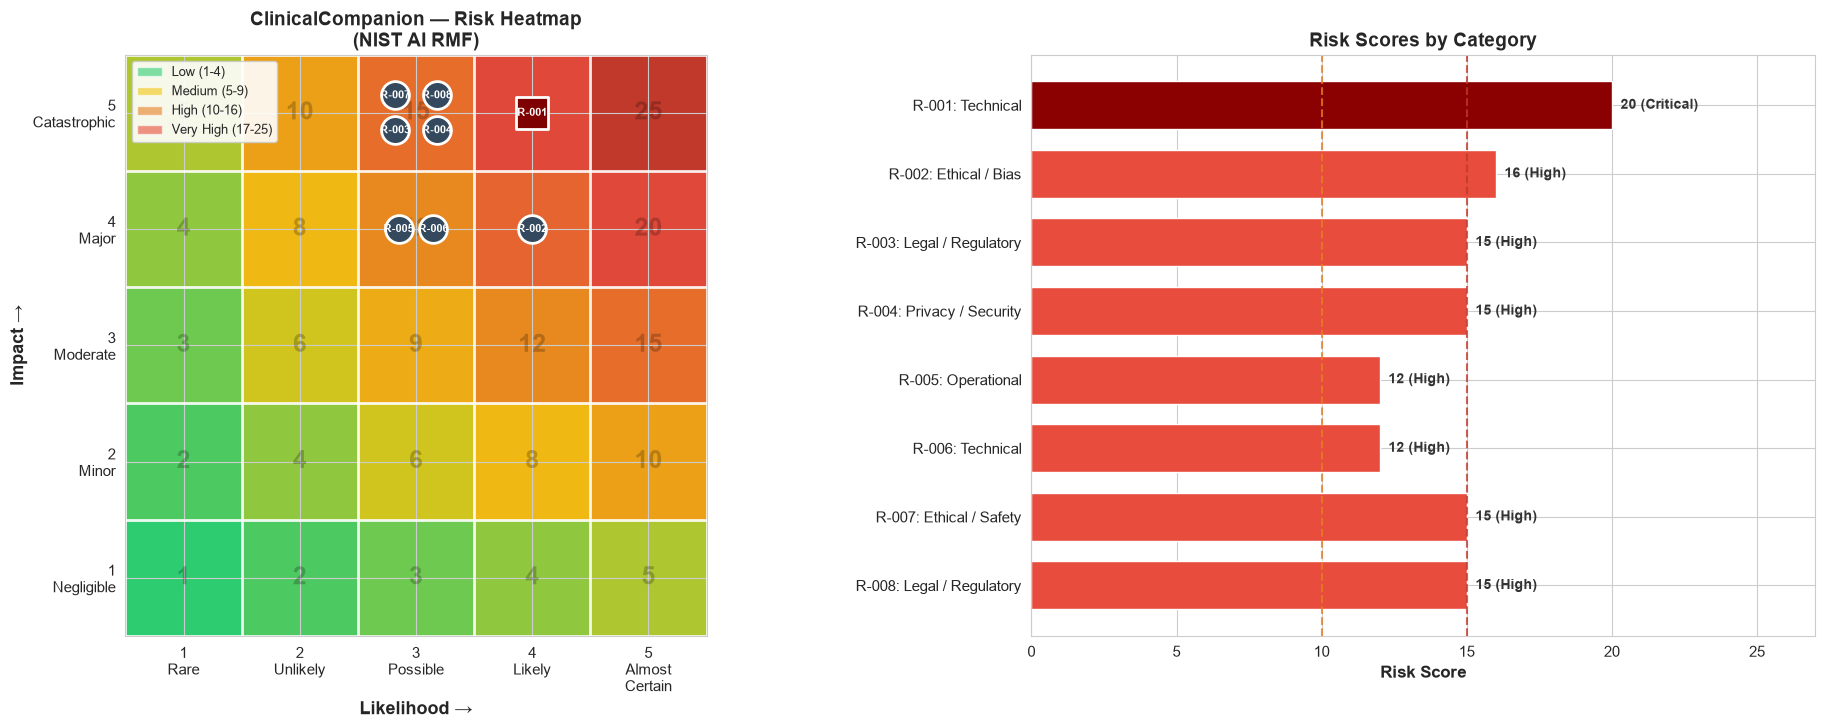

✅ Saved: results/risk_heatmap.png


In [11]:
# Step 4a: Create the risk heatmap visualization
from matplotlib.colors import LinearSegmentedColormap

# Re-load risk data (in case you modified risk_df above)
risk_df = pd.read_csv(DATA_DIR / 'risk_register.csv')

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8),
                                gridspec_kw={'width_ratios': [1.2, 1]})

# --- LEFT PANEL: 5×5 Risk Heatmap ---

# Score matrix for background coloring (each cell = likelihood × impact)
score_matrix = np.array([[(i+1)*(j+1) for j in range(5)] for i in range(5)])

# Color gradient: green (low risk) → red (high risk)
cmap = LinearSegmentedColormap.from_list('risk',
       ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b'], N=256)

# 🔧 TODO: Display the score_matrix as the heatmap background using imshow().
# Set origin='lower' so (1,1) is bottom-left.

# Each cell contains likelihood × impact
score_matrix = np.array([
    [(impact + 1) * (likelihood + 1) for likelihood in range(5)]
    for impact in range(5)
])

# Green-to-red risk gradient
cmap = LinearSegmentedColormap.from_list(
    "risk",
    [
        "#2ecc71",
        "#f1c40f",
        "#e67e22",
        "#e74c3c",
        "#c0392b"
    ],
    N=256
)

# Display heatmap background
ax1.imshow(
    score_matrix,
    origin="lower",
    cmap=cmap,
    vmin=1,
    vmax=25,
    extent=(-0.5, 4.5, -0.5, 4.5),
    interpolation="nearest",
    aspect="equal"
)

# 🔧 TODO: Draw white grid lines to separate cells (6 horizontal + 6 vertical).

# Draw white lines around the 25 cells
for boundary in np.arange(-0.5, 5.5, 1):
    ax1.axhline(
        boundary,
        color="white",
        linewidth=2,
        alpha=0.9
    )
    ax1.axvline(
        boundary,
        color="white",
        linewidth=2,
        alpha=0.9
    )

# 🔧 TODO: Plot each risk as a scatter point at position (likelihood-1, impact-1).
# Use different markers for Critical vs High priority risks.
# Handle overlapping risks by offsetting slightly.
# Annotate each point with its risk_id.

# Add risk score numbers to each cell
for impact_index in range(5):
    for likelihood_index in range(5):
        cell_score = (
            (likelihood_index + 1)
            * (impact_index + 1)
        )

        ax1.text(
            likelihood_index,
            impact_index,
            str(cell_score),
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
            alpha=0.22,
            zorder=1
        )

# Offsets prevent risks in the same cell from overlapping
offset_patterns = {
    1: [(0, 0)],
    2: [(-0.15, 0), (0.15, 0)],
    3: [
        (-0.17, -0.12),
        (0.17, -0.12),
        (0, 0.16)
    ],
    4: [
        (-0.18, -0.15),
        (0.18, -0.15),
        (-0.18, 0.15),
        (0.18, 0.15)
    ]
}



# 🔧 TODO: Add faint score numbers in each cell center (showing the L×I value).

# Group risks occupying the same likelihood-impact cell
position_groups = risk_df.groupby(
    ["likelihood", "impact"],
    sort=False
)

for (likelihood, impact), group in position_groups:
    offsets = offset_patterns.get(
        len(group),
        [(0, 0)] * len(group)
    )

    for (_, risk), (x_offset, y_offset) in zip(
        group.iterrows(),
        offsets
    ):
        x_position = likelihood - 1 + x_offset
        y_position = impact - 1 + y_offset

        is_critical = risk["priority"] == "Critical"

        marker = "s" if is_critical else "o"
        marker_size = 520 if is_critical else 400
        marker_color = "#7f0000" if is_critical else "#34495e"

        ax1.scatter(
            x_position,
            y_position,
            s=marker_size,
            marker=marker,
            color=marker_color,
            edgecolor="white",
            linewidth=2,
            zorder=3
        )

        ax1.annotate(
            risk["risk_id"],
            (x_position, y_position),
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            color="white",
            zorder=4
        )


# Axis labels and formatting (provided)
ax1.set_xlabel('Likelihood →', fontsize=13, fontweight='bold')
ax1.set_ylabel('Impact →', fontsize=13, fontweight='bold')
ax1.set_title('ClinicalCompanion — Risk Heatmap\n(NIST AI RMF)', fontsize=14, fontweight='bold')
ax1.set_xticks(range(5))
ax1.set_xticklabels(['1\nRare','2\nUnlikely','3\nPossible','4\nLikely','5\nAlmost\nCertain'])
ax1.set_yticks(range(5))
ax1.set_yticklabels(['1\nNegligible','2\nMinor','3\nModerate','4\nMajor','5\nCatastrophic'])
ax1.legend(handles=[
    mpatches.Patch(fc='#2ecc71', alpha=0.6, label='Low (1-4)'),
    mpatches.Patch(fc='#f1c40f', alpha=0.6, label='Medium (5-9)'),
    mpatches.Patch(fc='#e67e22', alpha=0.6, label='High (10-16)'),
    mpatches.Patch(fc='#e74c3c', alpha=0.6, label='Very High (17-25)'),
], loc='upper left', fontsize=9, framealpha=0.9)


# --- RIGHT PANEL: Risk Score Bar Chart ---

# 🔧 TODO: Create a horizontal bar chart showing each risk's score.
# Color critical risks differently from high risks.
# Add score and priority labels to the right of each bar.
# Add reference lines at scores 10 and 15.

y_positions = np.arange(len(risk_df))

priority_colors = {
    "Critical": "#8b0000",
    "High": "#e74c3c",
    "Medium": "#f1c40f",
    "Low": "#2ecc71"
}

bar_colors = risk_df["priority"].map(priority_colors)

bars = ax2.barh(
    y_positions,
    risk_df["risk_score"],
    color=bar_colors,
    edgecolor="white",
    height=0.7
)

# Add score and priority labels
for bar, (_, risk) in zip(bars, risk_df.iterrows()):
    ax2.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{risk['risk_score']} ({risk['priority']})",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

# Add reference lines at scores 10 and 15
ax2.axvline(
    x=10,
    color="#e67e22",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

ax2.axvline(
    x=15,
    color="#c0392b",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# Axis formatting (provided)
ax2.set_yticks(range(len(risk_df)))
ax2.set_yticklabels([f"{r['risk_id']}: {r['risk_category']}" for _, r in risk_df.iterrows()])
ax2.set_xlabel('Risk Score', fontsize=12, fontweight='bold')
ax2.set_title('Risk Scores by Category', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 27)
ax2.invert_yaxis()

# Save
plt.tight_layout(pad=3)
plt.savefig(RESULTS_DIR / 'risk_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/risk_heatmap.png")

### 4b. Create the pre vs. post-mitigation comparison chart

🔧 **TODO:** Create a grouped bar chart comparing pre-mitigation and post-mitigation risk scores:
- Side-by-side bars (red = pre, green = post) for each risk
- Score labels on top of each bar
- Percentage reduction annotated above each pair
- Reference lines at scores 10 and 15
- Save as `results/risk_mitigation_comparison.png`

*Hint: Use `np.arange()` for bar positions and offset by bar width/2 for grouping*

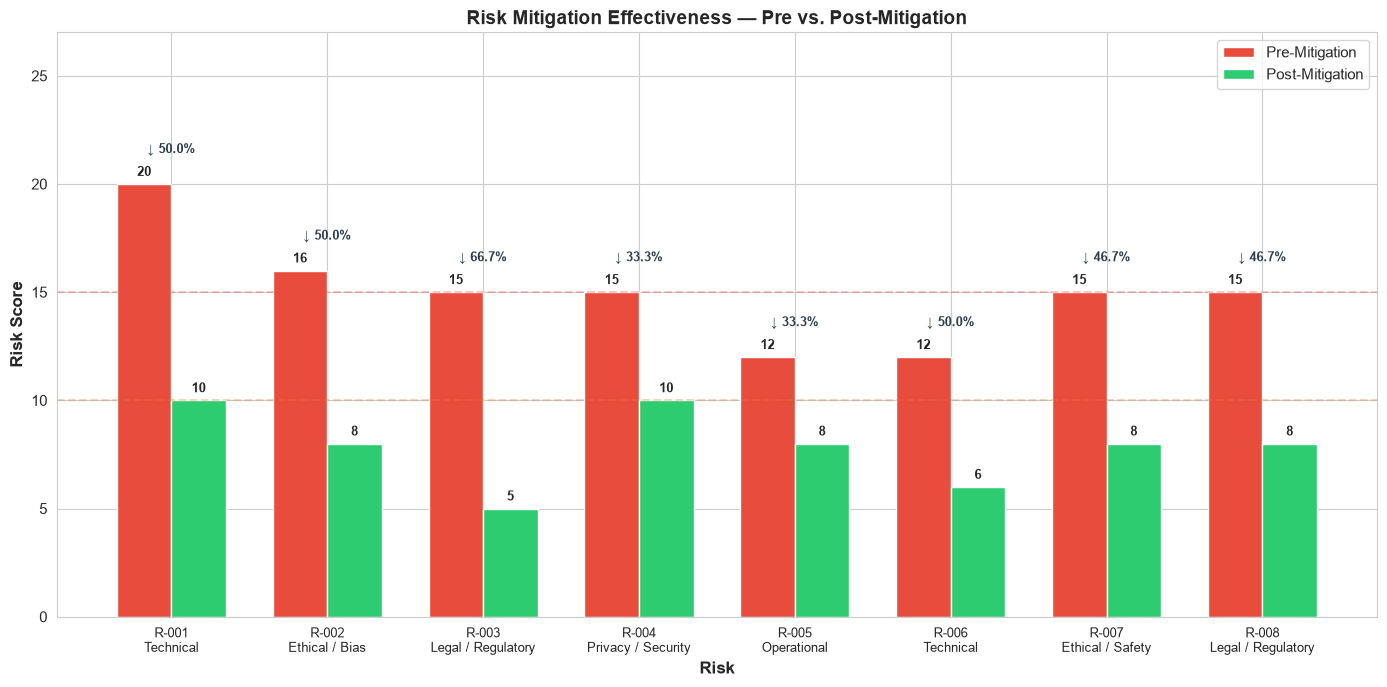

✅ Saved: results/risk_mitigation_comparison.png


In [12]:
# Step 4b: Create pre vs. post-mitigation comparison

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(risk_df))
w = 0.35  # bar width

# 🔧 TODO: Create two sets of bars (grouped bar chart):
# - Pre-mitigation bars (red) using risk_score, offset left
# - Post-mitigation bars (green) using residual_score, offset right
# Hint: Offset each set by half the bar width from the x positions.

pre_bars = ax.bar(
    x - w / 2,
    risk_df["risk_score"],
    width=w,
    color="#e74c3c",
    edgecolor="white",
    label="Pre-Mitigation"
)

post_bars = ax.bar(
    x + w / 2,
    risk_df["residual_score"],
    width=w,
    color="#2ecc71",
    edgecolor="white",
    label="Post-Mitigation"
)

# 🔧 TODO: Add score labels on top of each bar.

for bars in [pre_bars, post_bars]:
    for bar in bars:
        score = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            score + 0.25,
            f"{score:.0f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )


# 🔧 TODO: Annotate the percentage reduction above each risk pair.

# Calculate percentage reduction in this cell because risk_df
# was reloaded in Step 4a
reduction_pct = (
    (
        risk_df["risk_score"]
        - risk_df["residual_score"]
    )
    / risk_df["risk_score"]
) * 100

for position, (_, risk) in enumerate(risk_df.iterrows()):
    pair_height = max(
        risk["risk_score"],
        risk["residual_score"]
    )

    ax.text(
        x[position],
        pair_height + 1.3,
        f"↓ {reduction_pct.iloc[position]:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#2c3e50"
    )

# Axis formatting (provided)
ax.set_xlabel('Risk', fontsize=12, fontweight='bold')
ax.set_ylabel('Risk Score', fontsize=12, fontweight='bold')
ax.set_title('Risk Mitigation Effectiveness — Pre vs. Post-Mitigation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['risk_id']}\n{r['risk_category']}" for _, r in risk_df.iterrows()], fontsize=9)
ax.legend(fontsize=11)
ax.set_ylim(0, 27)
ax.axhline(y=15, color='#e74c3c', ls='--', alpha=0.3)
ax.axhline(y=10, color='#e67e22', ls='--', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'risk_mitigation_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/risk_mitigation_comparison.png")

---
## Step 5: Vendor Evaluation Visualization

**Time estimate: ~30 minutes**

Load the vendor assessment data and create a governance scorecard. The vendor (FoundationHealth Inc.) has been evaluated across 27 criteria in 5 categories.

*Full evaluation narrative goes in `governance_workbook.xlsx` → Sheet "Vendor Evaluation"*

### 5a. Load and analyze vendor data

🔧 **TODO:** Load `vendor_assessment.csv` and `vendor_profile.json`, then:
1. Calculate the score percentage for each category (score / max_score × 100)
2. Calculate the overall vendor score
3. Print a summary showing each category's score and the overall rating

*Scoring guide: ≥80% = Low Risk, 60-79% = Medium Risk, <60% = High Risk*

In [13]:
# Step 5a: Load and analyze vendor assessment data

vendor_df = pd.read_csv(DATA_DIR / 'vendor_assessment.csv')
with open(DATA_DIR / 'vendor_profile.json') as f:
    vendor = json.load(f)

# 🔧 TODO: Group vendor_df by 'category' and calculate:
# - Total score per category (sum of 'score' column)
# - Max possible score per category (sum of 'max_score' column)
# - Score percentage for each category
# Hint: Use pandas groupby with aggregation, then compute the percentage.

category_scores = (
    vendor_df
    .groupby("category", sort=False)
    .agg(
        score=("score", "sum"),
        max_score=("max_score", "sum")
    )
    .reset_index()
)

category_scores["score_percentage"] = (
    category_scores["score"]
    / category_scores["max_score"]
) * 100

# 🔧 TODO: Print a summary showing each category's score, max, percentage, and risk level.
# Scoring guide: ≥80% = Low Risk, 60-79% = Medium Risk, <60% = High Risk

def assign_vendor_risk(percentage):
    if percentage >= 80:
        return "Low Risk"
    elif percentage >= 60:
        return "Medium Risk"
    else:
        return "High Risk"


category_scores["risk_level"] = (
    category_scores["score_percentage"]
    .apply(assign_vendor_risk)
)

print("=" * 80)
print(
    f"VENDOR ASSESSMENT — "
    f"{vendor['company']['name']}"
)
print("=" * 80)

for _, row in category_scores.iterrows():
    print(
        f"{row['category']}:\n"
        f"  Score: {row['score']:.0f}/"
        f"{row['max_score']:.0f}\n"
        f"  Percentage: "
        f"{row['score_percentage']:.1f}%\n"
        f"  Rating: {row['risk_level']}\n"
    )

# 🔧 TODO: Calculate and print the overall vendor score (total score / total max × 100).

overall_score = vendor_df["score"].sum()
overall_max_score = vendor_df["max_score"].sum()

overall_percentage = (
    overall_score / overall_max_score
) * 100

overall_risk_level = assign_vendor_risk(
    overall_percentage
)

print("-" * 80)
print("OVERALL VENDOR RESULT")
print("-" * 80)

print(
    f"Overall score: "
    f"{overall_score}/{overall_max_score}"
)

print(
    f"Overall percentage: "
    f"{overall_percentage:.1f}%"
)

print(
    f"Overall rating: "
    f"{overall_risk_level}"
)


VENDOR ASSESSMENT — FoundationHealth Inc.
Model Transparency & Documentation:
  Score: 15/25
  Percentage: 60.0%
  Rating: Medium Risk

Data Privacy & Security:
  Score: 25/30
  Percentage: 83.3%
  Rating: Low Risk

Model Governance & Lifecycle:
  Score: 15/25
  Percentage: 60.0%
  Rating: Medium Risk

Contractual & Business Continuity:
  Score: 18/30
  Percentage: 60.0%
  Rating: Medium Risk

Regulatory & Ethical Alignment:
  Score: 15/25
  Percentage: 60.0%
  Rating: Medium Risk

--------------------------------------------------------------------------------
OVERALL VENDOR RESULT
--------------------------------------------------------------------------------
Overall score: 88/135
Overall percentage: 65.2%
Overall rating: Medium Risk


### 5b. Create vendor scorecard visualization

🔧 **TODO:** Create a figure with two subplots:

**Left — Horizontal bar chart:**
- One bar per vendor category showing score percentage
- Color-coded: green (≥80%), yellow (60-79%), red (<60%)
- Score labels showing "XX% (score/max)" on each bar
- Reference lines at 60% and 80%

**Right — Radar/spider chart:**
- Categories around the perimeter
- Score percentages as the radar values
- Reference circles at 60% and 80%

Save as `results/vendor_evaluation_chart.png`.

*Hint: For the radar chart, use `fig.add_subplot(122, polar=True)` and compute angles with `np.linspace(0, 2*np.pi, n, endpoint=False)`*

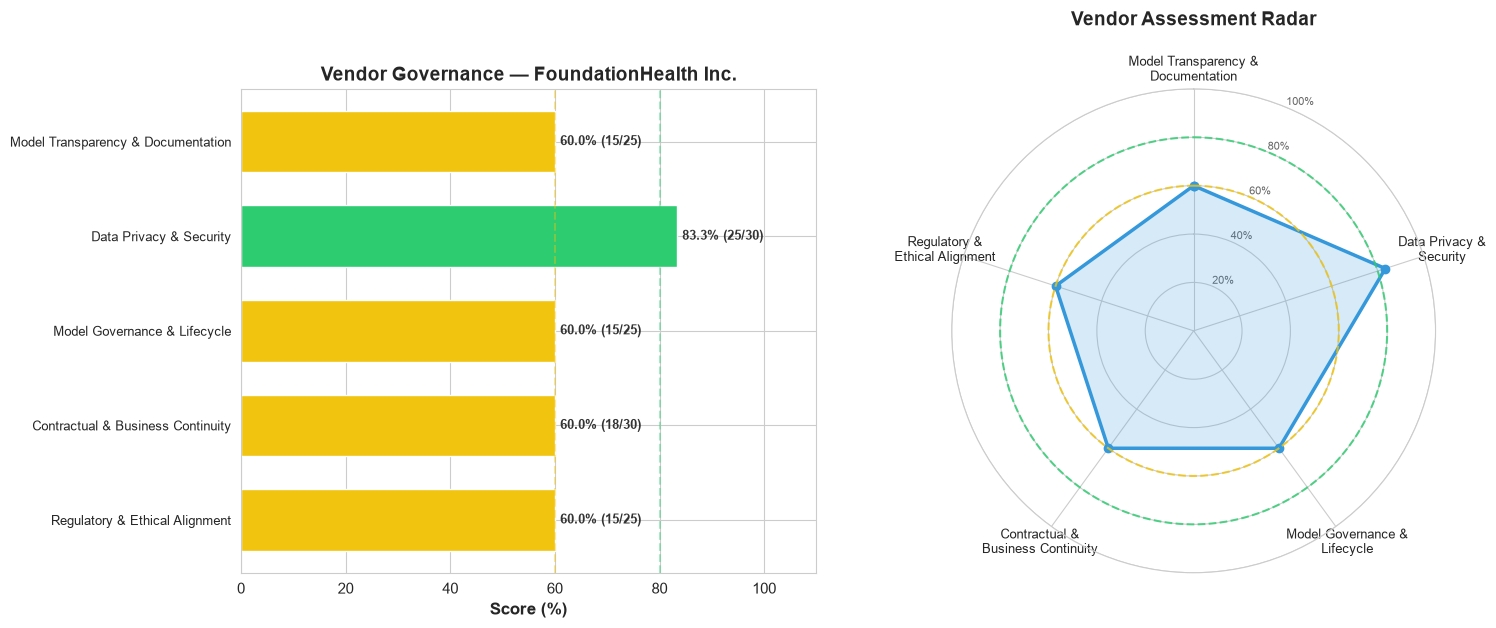

✅ Saved: results/vendor_evaluation_chart.png


In [14]:
# Step 5b: Create vendor scorecard visualization

fig, (ax1, ax2_placeholder) = plt.subplots(1, 2, figsize=(16, 7))

# --- LEFT PANEL: Horizontal Bar Chart ---

# 🔧 TODO: Create a horizontal bar chart with one bar per category showing score percentage.
# Color-code by risk level: green (≥80%), yellow (60-79%), red (<60%).
# Add score labels showing percentage and raw score to the right of each bar.
categories = category_scores["category"].tolist()
percentages = category_scores["score_percentage"].tolist()
y_positions = np.arange(len(categories))

bar_colors = [
    "#2ecc71" if percentage >= 80
    else "#f1c40f" if percentage >= 60
    else "#e74c3c"
    for percentage in percentages
]

bars = ax1.barh(
    y_positions,
    percentages,
    color=bar_colors,
    edgecolor="white",
    height=0.65
)

ax1.set_yticks(y_positions)
ax1.set_yticklabels(categories, fontsize=9)

# Add percentage and raw score labels
for bar, (_, row) in zip(
    bars,
    category_scores.iterrows()
):
    ax1.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        (
            f"{row['score_percentage']:.1f}% "
            f"({row['score']:.0f}/"
            f"{row['max_score']:.0f})"
        ),
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold",
        color="#333333"
    )


# Reference lines and formatting (provided)
ax1.set_xlabel('Score (%)', fontsize=12, fontweight='bold')
ax1.set_title(f"Vendor Governance — {vendor['company']['name']}", fontsize=14, fontweight='bold')
ax1.set_xlim(0, 110)
ax1.axvline(x=80, color='#2ecc71', ls='--', alpha=0.4)
ax1.axvline(x=60, color='#f1c40f', ls='--', alpha=0.4)
ax1.invert_yaxis()

# --- RIGHT PANEL: Radar/Spider Chart ---
ax2_placeholder.remove()  # Remove placeholder to create polar subplot
ax2 = fig.add_subplot(122, polar=True)

# 🔧 TODO: Create a radar chart showing category scores:
# 1. Calculate evenly-spaced angles around the circle (one per category)
# 2. Close the polygon by repeating the first value at the end
# 3. Plot the line and fill the area
# 4. Add reference circles at 60% and 80%
# 5. Set category names as tick labels around the perimeter
number_of_categories = len(categories)

angles = np.linspace(
    0,
    2 * np.pi,
    number_of_categories,
    endpoint=False
).tolist()

radar_values = percentages.copy()

# Close the radar polygon
angles_closed = angles + [angles[0]]
values_closed = radar_values + [radar_values[0]]

# Plot vendor scores
ax2.plot(
    angles_closed,
    values_closed,
    color="#3498db",
    linewidth=2.5,
    marker="o",
    label="Vendor score"
)

ax2.fill(
    angles_closed,
    values_closed,
    color="#3498db",
    alpha=0.20
)

# Reference circles at 60% and 80%
reference_angles = np.linspace(
    0,
    2 * np.pi,
    360
)

ax2.plot(
    reference_angles,
    np.full_like(reference_angles, 60),
    color="#f1c40f",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label="60% threshold"
)

ax2.plot(
    reference_angles,
    np.full_like(reference_angles, 80),
    color="#2ecc71",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label="80% threshold"
)

# Shorten category names for the radar labels
radar_labels = [
    category.replace(" & ", " &\n")
    for category in categories
]

ax2.set_xticks(angles)
ax2.set_xticklabels(
    radar_labels,
    fontsize=9
)

# Begin at the top and move clockwise
ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)

ax2.set_yticks([20, 40, 60, 80, 100])
ax2.set_yticklabels(
    ["20%", "40%", "60%", "80%", "100%"],
    fontsize=8,
    color="#666666"
)

ax2.set_ylim(0, 100)
ax2.set_title('Vendor Assessment Radar\n', fontsize=14, fontweight='bold')

# Save
plt.tight_layout(pad=3)
plt.savefig(RESULTS_DIR / 'vendor_evaluation_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/vendor_evaluation_chart.png")

---
## Step 6: Model Card — Performance Analysis

**Time estimate: ~30 minutes**

Visualize disaggregated performance metrics for the Model Card fairness analysis. The Model Card framework (Mitchell et al., 2019) requires showing how the model performs across different subgroups, not just overall.

*Full Model Card content goes in `governance_workbook.xlsx` → Sheet "Model Card"*

### 6a. Analyze disaggregated performance

🔧 **TODO:** Load `performance_metrics.csv` and:
1. Filter for "Top-3 Diagnostic Accuracy" metrics across all subgroups
2. Identify which subgroups fall BELOW the 90% target
3. Print a summary of failing subgroups with their accuracy values

*Think about: What are the governance implications of these performance gaps? How do they relate to EU AI Act Article 10 (dataset representativeness)?*

In [15]:
# Step 6a: Load and analyze disaggregated performance metrics

perf_df = pd.read_csv(DATA_DIR / 'performance_metrics.csv')

# 🔧 TODO: Filter for rows where metric_name is 'Top-3 Diagnostic Accuracy'.

accuracy_df = perf_df[
    perf_df["metric_name"]
    == "Top-3 Diagnostic Accuracy"
].copy()

# Convert target to numeric after filtering
accuracy_df["target_numeric"] = pd.to_numeric(
    accuracy_df["target"],
    errors="coerce"
)

print("=" * 75)
print("TOP-3 DIAGNOSTIC ACCURACY BY SUBGROUP")
print("=" * 75)

print(
    accuracy_df[
        [
            "subgroup",
            "value",
            "target_numeric",
            "sample_size",
            "meets_target"
        ]
    ].to_string(index=False)
)

# 🔧 TODO: Identify which subgroups fall BELOW the 90% target.
# Print each failing subgroup with its accuracy value.
below_target_df = accuracy_df[
    accuracy_df["value"]
    < accuracy_df["target_numeric"]
].copy()

# Calculate distance from the target
below_target_df["performance_gap"] = (
    below_target_df["target_numeric"]
    - below_target_df["value"]
)

# Show the largest gaps first
below_target_df = below_target_df.sort_values(
    "performance_gap",
    ascending=False
)

print("\n⚠️ SUBGROUPS BELOW THE 90% TARGET:")
print("-" * 75)

for _, row in below_target_df.iterrows():
    print(
        f"• {row['subgroup']}: "
        f"{row['value']:.1f}% "
        f"(gap: {row['performance_gap']:.1f} "
        f"percentage points; "
        f"sample: {row['sample_size']:,})"
    )

print(
    f"\nTotal subgroups below target: "
    f"{len(below_target_df)}"
)

# 🔧 TODO: Think about the governance implications — which gaps are most concerning
# for EU AI Act Article 10 (dataset representativeness)?
print("\nGOVERNANCE IMPLICATIONS:")
print("-" * 75)

print(
    "Rare Diseases is the most significant gap, with "
    "71.2% accuracy and the smallest evaluated sample. "
    "This indicates limited representation and requires "
    "additional data and validation."
)

print(
    "Multi-morbidity (4+) reaches only 74.0%, suggesting "
    "that the model may not adequately represent complex "
    "clinical cases."
)

print(
    "Non-English Notes reaches 84.3%, indicating possible "
    "language representation and translation issues that "
    "could produce unequal performance."
)

print(
    "Age 65+ is slightly below target at 88.9%. Because "
    "older patients may have more complex clinical needs, "
    "this subgroup should receive continued monitoring."
)

print(
    "These disparities indicate potential dataset "
    "representativeness gaps relevant to EU AI Act "
    "Article 10 and should be addressed before broad "
    "deployment."
)

TOP-3 DIAGNOSTIC ACCURACY BY SUBGROUP
            subgroup  value  target_numeric  sample_size meets_target
             Overall   91.7            90.0        45000          Yes
                Male   92.1            90.0        23400          Yes
              Female   91.3            90.0        21600          Yes
           Age 18-40   93.5            90.0        11200          Yes
           Age 41-64   92.0            90.0        19800          Yes
             Age 65+   88.9            90.0        14000           No
      Cardiovascular   94.1            90.0         8500          Yes
        Neurological   90.3            90.0         6200          Yes
       Rare Diseases   71.2            90.0         1035           No
   Non-English Notes   84.3            90.0         5400           No
Multi-morbidity (4+)   74.0            90.0         7650           No

⚠️ SUBGROUPS BELOW THE 90% TARGET:
---------------------------------------------------------------------------
• Rare Dis

### 6b. Create disaggregated performance bar chart

🔧 **TODO:** Create a bar chart showing Top-3 Diagnostic Accuracy by subgroup:
- One bar per subgroup
- Color-coded: green (≥90%), yellow (85-89%), orange (80-84%), red (<80%)
- The "Overall" bar highlighted with a distinct border
- Reference lines at 90%, 85%, and 80% thresholds
- Value labels on top of each bar
- Rotated x-axis labels for readability

Save as `results/model_card_performance.png`.

*Print a list of subgroups below the 85% threshold — these need mitigation.*

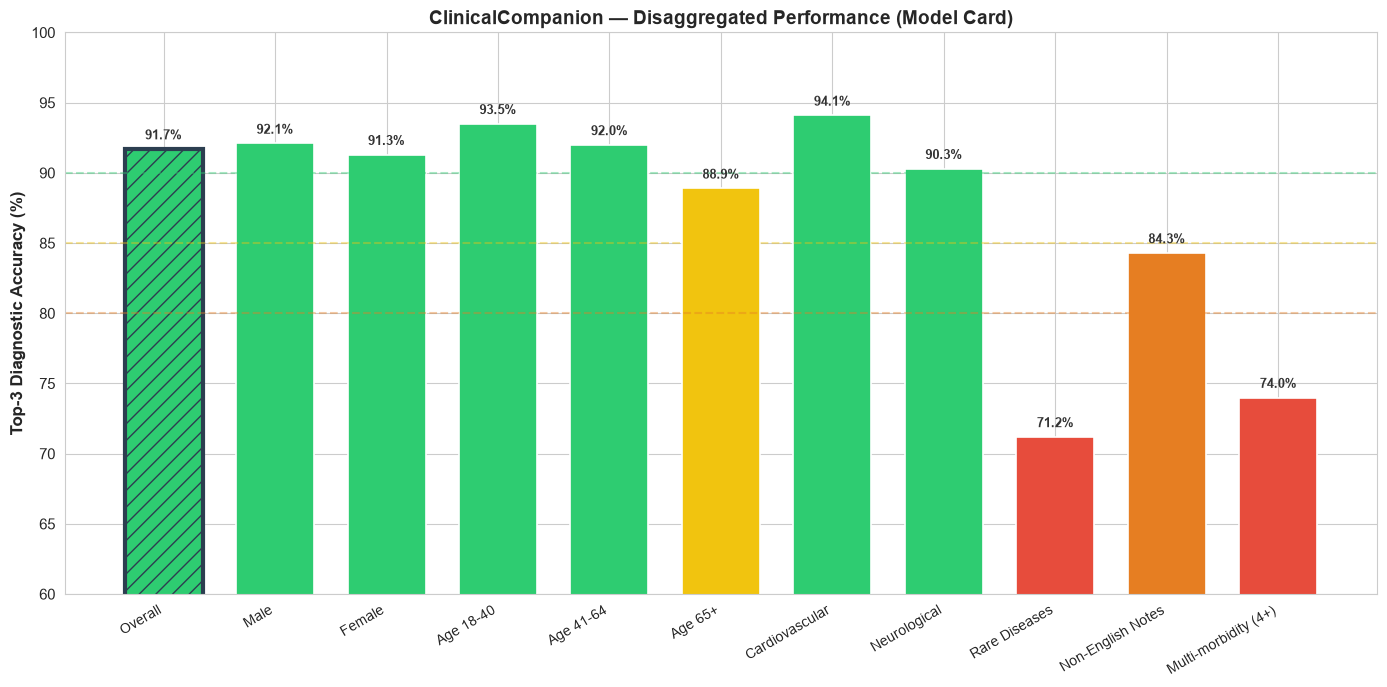


⚠️  SUBGROUPS BELOW 85% THRESHOLD:
• Rare Diseases: 71.2%
• Multi-morbidity (4+): 74.0%
• Non-English Notes: 84.3%
Total requiring mitigation: 3
✅ Saved: results/model_card_performance.png


In [16]:
# Step 6b: Create disaggregated performance visualization

fig, ax = plt.subplots(figsize=(14, 7))

# 🔧 TODO: Create a bar chart with one bar per subgroup showing Top-3 accuracy.
# Color-code by performance: green (≥90%), yellow (85-89%), orange (80-84%), red (<80%).

x_positions = np.arange(len(accuracy_df))

performance_colors = [
    "#2ecc71" if value >= 90
    else "#f1c40f" if value >= 85
    else "#e67e22" if value >= 80
    else "#e74c3c"
    for value in accuracy_df["value"]
]

bars = ax.bar(
    x_positions,
    accuracy_df["value"],
    color=performance_colors,
    edgecolor="white",
    linewidth=1.2,
    width=0.7
)

# 🔧 TODO: Highlight the "Overall" bar with a distinct border to make it stand out.
for position, subgroup in enumerate(
    accuracy_df["subgroup"]
):
    if subgroup == "Overall":
        bars[position].set_edgecolor("#2c3e50")
        bars[position].set_linewidth(3)
        bars[position].set_hatch("//")

# 🔧 TODO: Add value labels on top of each bar showing the percentage.
for bar, value in zip(
    bars,
    accuracy_df["value"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#333333"
    )

# Reference lines and formatting (provided)
ax.axhline(y=90, color='#2ecc71', ls='--', alpha=0.4)
ax.axhline(y=85, color='#f1c40f', ls='--', alpha=0.4)
ax.axhline(y=80, color='#e67e22', ls='--', alpha=0.4)
ax.set_xticks(range(len(accuracy_df)))
ax.set_xticklabels(accuracy_df['subgroup'], fontsize=10, rotation=30, ha='right')
ax.set_ylabel('Top-3 Diagnostic Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('ClinicalCompanion — Disaggregated Performance (Model Card)', fontsize=14, fontweight='bold')
ax.set_ylim(60, 100)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_card_performance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 🔧 TODO: Print a list of subgroups below 85% threshold — these need mitigation.
mitigation_df = (
    accuracy_df[
        accuracy_df["value"] < 85
    ]
    .sort_values("value")
)

print("\n⚠️  SUBGROUPS BELOW 85% THRESHOLD:")

for _, row in mitigation_df.iterrows():
    print(
        f"• {row['subgroup']}: "
        f"{row['value']:.1f}%"
    )

print(
    f"Total requiring mitigation: "
    f"{len(mitigation_df)}"
)

print("✅ Saved: results/model_card_performance.png")

---
## Step 7: Monitoring & Incident Response Dashboard

**Time estimate: ~30 minutes**

Create a multi-panel monitoring dashboard that visualizes KPIs, incident taxonomy, and response framework.

*Full monitoring plan goes in `governance_workbook.xlsx` → Sheet "Monitoring & Incidents"*

### 7a. Load monitoring data

🔧 **TODO:** Load the three monitoring data files:
- `monitoring_kpis.csv` — 16 KPI definitions
- `incident_types.csv` — 10 AI-specific incident types
- `severity_levels.csv` — S1-S4 severity levels

Print a brief summary of each (number of KPIs by dimension, number of incident types, severity levels).

In [17]:
# Step 7a: Load monitoring data files

kpi_df = pd.read_csv(DATA_DIR / 'monitoring_kpis.csv')
incident_df = pd.read_csv(DATA_DIR / 'incident_types.csv')
severity_df = pd.read_csv(DATA_DIR / 'severity_levels.csv')

# 🔧 TODO: Print a brief summary of each dataset:
# 1. Number of KPIs and how many per dimension
# 2. Number of incident types
# 3. Severity levels with their labels and response times
print("=" * 70)
print("MONITORING AND INCIDENT RESPONSE DATA SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# 1. KPI summary
# ------------------------------------------------------------

kpi_counts = (
    kpi_df
    .groupby("dimension", sort=False)
    .size()
)

print(f"\nMONITORING KPIs: {len(kpi_df)} total")
print("-" * 40)

for dimension, count in kpi_counts.items():
    print(f"• {dimension}: {count} KPIs")

# ------------------------------------------------------------
# 2. Incident types summary
# ------------------------------------------------------------

number_of_incident_types = (
    incident_df["incident_type"].nunique()
)

print(
    f"\nAI INCIDENT TYPES: "
    f"{number_of_incident_types} total"
)

print("-" * 40)

for _, row in incident_df.iterrows():
    print(
        f"• {row['incident_id']}: "
        f"{row['incident_type']} "
        f"({row['severity_range']})"
    )

# ------------------------------------------------------------
# 3. Severity levels summary
# ------------------------------------------------------------

number_of_severity_levels = (
    severity_df["severity"].nunique()
)

print(
    f"\nSEVERITY LEVELS: "
    f"{number_of_severity_levels} total"
)

print("-" * 40)

for _, row in severity_df.iterrows():
    print(
        f"• {row['severity']} — "
        f"{row['label']}: "
        f"{row['response_time']} "
        f"({row['response_hours']} hours)"
    )

MONITORING AND INCIDENT RESPONSE DATA SUMMARY

MONITORING KPIs: 16 total
----------------------------------------
• Clinical Performance: 5 KPIs
• Fairness & Bias: 4 KPIs
• Operational: 4 KPIs
• Data Quality: 3 KPIs

AI INCIDENT TYPES: 10 total
----------------------------------------
• INC-01: Clinical Hallucination (S2-S1)
• INC-02: Harmful Suggestion (S1)
• INC-03: Bias-Related Harm (S2-S1)
• INC-04: Privacy Breach (S1)
• INC-05: Performance Degradation (S3-S2)
• INC-06: Adversarial Manipulation (S2-S1)
• INC-07: Vendor Service Disruption (S3-S2)
• INC-08: Data Pipeline Failure (S1)
• INC-09: Unauthorized Access (S2-S1)
• INC-10: Regulatory Non-Compliance (S3-S2)

SEVERITY LEVELS: 4 total
----------------------------------------
• S1 — Critical: Immediate (30 min) (0.5 hours)
• S2 — High: Within 2 hours (2.0 hours)
• S3 — Medium: Within 24 hours (24.0 hours)
• S4 — Low: Within 1 week (168.0 hours)


### 7b. Create monitoring dashboard (4 panels)

🔧 **TODO:** Create a 2×2 dashboard with these panels:

**Panel 1 (top-left): KPI Status vs. Targets**
- Select 6 key KPIs and show current values as bars
- Overlay target values as dashed horizontal lines
- Color: green if meeting target, red if below

**Panel 2 (top-right): Incident Distribution**
- Pie chart showing distribution across severity levels (S1-S4)

**Panel 3 (bottom-left): Response Time SLAs**
- Horizontal bar chart showing response time for each severity level
- Use log scale for x-axis (ranges from 0.5h to 168h)
- Color-coded by severity (red→green)

**Panel 4 (bottom-right): Monitoring Coverage**
- Bar chart showing number of KPIs per dimension
- Shows which areas have more/less monitoring coverage

Save as `results/monitoring_dashboard.png`.

*Hint: Use `plt.subplots(2, 2, figsize=(16, 12))` for the 4-panel layout*

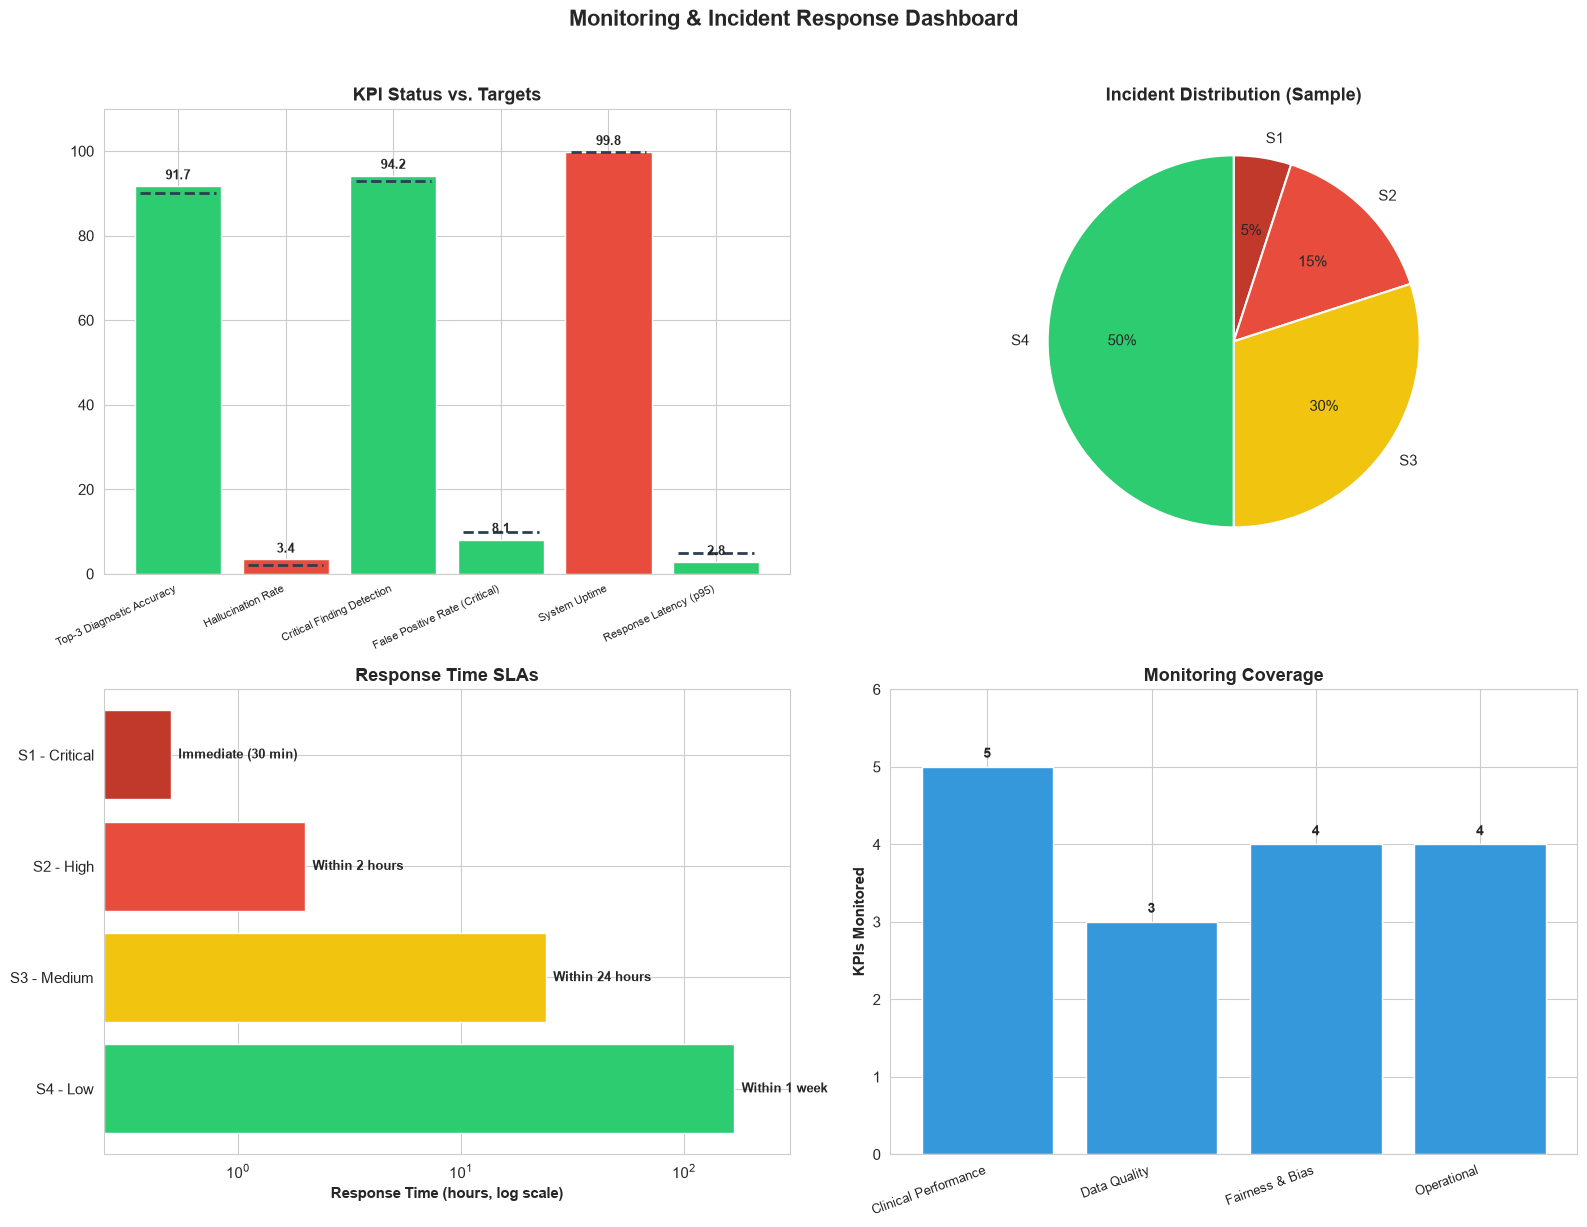

✅ Saved: results/monitoring_dashboard.png


In [19]:
# Step 7b: Create 4-panel monitoring dashboard

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Panel 1 (top-left): KPI Status vs. Targets ---
ax = axes[0, 0]
# Select 6 key KPIs to display
kpis_show = ['Top-3 Diagnostic Accuracy', 'Hallucination Rate', 'Critical Finding Detection',
             'False Positive Rate (Critical)', 'System Uptime', 'Response Latency (p95)']
# 🔧 TODO: Look up the current values and targets for these KPIs from the data.
# Create bars colored green if meeting target, red if below.
# Overlay target values as dashed lines on each bar.

overall_metrics = perf_df[
    perf_df['subgroup'] == 'Overall'
].set_index('metric_name')['value']

current_values = np.array([
    overall_metrics['Top-3 Diagnostic Accuracy'],
    overall_metrics['Hallucination Rate'],
    overall_metrics['Critical Finding Detection'],
    overall_metrics['False Positive Rate (Critical)'],
    99.8,
    overall_metrics['Avg Response Latency']
])

target_values = np.array([90.0, 2.0, 93.0, 10.0, 99.9, 5.0])

higher_is_better = np.array([
    True, False, True, False, True, False
])

meets_target = np.where(
    higher_is_better,
    current_values >= target_values,
    current_values <= target_values
)

kpi_colors = [
    '#2ecc71' if meets else '#e74c3c'
    for meets in meets_target
]

kpi_positions = np.arange(len(kpis_show))

kpi_bars = ax.bar(
    kpi_positions,
    current_values,
    color=kpi_colors,
    edgecolor='white'
)

for position, target in enumerate(target_values):
    ax.hlines(
        target,
        position - 0.35,
        position + 0.35,
        color='#2c3e50',
        linestyle='--',
        linewidth=2
    )

for bar, value in zip(kpi_bars, current_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f'{value:.1f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_xticks(kpi_positions)
ax.set_xticklabels(kpis_show, fontsize=8, rotation=25, ha='right')
ax.set_ylim(0, 110)

ax.set_title('KPI Status vs. Targets', fontsize=13, fontweight='bold')

# --- Panel 2 (top-right): Incident Distribution ---
ax = axes[0, 1]
# 🔧 TODO: Create a pie chart showing the distribution of incidents across severity levels.
# Use severity-appropriate colors (red for critical, green for low).

incident_counts = [1, 3, 6, 10]
incident_labels = ['S1', 'S2', 'S3', 'S4']
incident_colors = ['#c0392b', '#e74c3c', '#f1c40f', '#2ecc71']

ax.pie(
    incident_counts,
    labels=incident_labels,
    colors=incident_colors,
    autopct='%1.0f%%',
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

ax.set_title('Incident Distribution (Sample)', fontsize=13, fontweight='bold')

# --- Panel 3 (bottom-left): Response Time SLAs ---
ax = axes[1, 0]
sev_colors = ['#c0392b', '#e74c3c', '#f1c40f', '#2ecc71']
sev_names = [f"{r['severity']} - {r['label']}" for _, r in severity_df.iterrows()]

# 🔧 TODO: Create a horizontal bar chart showing response time for each severity level.
# Use the response_hours column from severity_df.
# Add time labels to the right of each bar.
# Use a log scale for the x-axis since values range widely.

response_hours = severity_df['response_hours'].astype(float).to_numpy()
severity_positions = np.arange(len(severity_df))
log_start = 0.25

response_bars = ax.barh(
    severity_positions,
    response_hours - log_start,
    left=log_start,
    color=sev_colors,
    edgecolor='white'
)

ax.set_yticks(severity_positions)
ax.set_yticklabels(sev_names)

for position, (_, row) in enumerate(severity_df.iterrows()):
    hours = float(row['response_hours'])

    ax.text(
        hours * 1.08,
        position,
        row['response_time'],
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_xscale('log')
ax.set_xlim(0.25, 300)

ax.set_xlabel('Response Time (hours, log scale)', fontweight='bold')
ax.set_title('Response Time SLAs', fontsize=13, fontweight='bold')
ax.invert_yaxis()

# --- Panel 4 (bottom-right): Monitoring Coverage by Dimension ---
ax = axes[1, 1]
dim_counts = kpi_df.groupby('dimension').size().reset_index(name='count')

# 🔧 TODO: Create a bar chart showing number of KPIs per dimension.
# Add count labels on top of each bar.

dimension_positions = np.arange(len(dim_counts))

coverage_bars = ax.bar(
    dimension_positions,
    dim_counts['count'],
    color='#3498db',
    edgecolor='white'
)

ax.set_xticks(dimension_positions)
ax.set_xticklabels(
    dim_counts['dimension'],
    fontsize=9,
    rotation=20,
    ha='right'
)

for bar, count in zip(coverage_bars, dim_counts['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.08,
        str(count),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_ylim(0, dim_counts['count'].max() + 1)

ax.set_ylabel('KPIs Monitored', fontweight='bold')
ax.set_title('Monitoring Coverage', fontsize=13, fontweight='bold')

# Save
plt.suptitle('Monitoring & Incident Response Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'monitoring_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: results/monitoring_dashboard.png")

---
## Step 8: Executive Summary Dashboard

**Time estimate: ~15 minutes**

Create a board-ready visualization summarizing the overall governance readiness.

*Full executive summary goes in `governance_workbook.xlsx` → Sheet "Executive Summary"*

### 8a. Create executive readiness dashboard

🔧 **TODO:** Create a figure with two panels:

**Left — Compliance Readiness Bars:**
- Show readiness percentages for 6 areas: EU AI Act Conformity, MDR CE Marking, GDPR DPIA, Technical Docs, Post-Market Monitoring, Human Oversight
- Assign realistic readiness percentages based on your analysis throughout this notebook
- Color-code: green (≥75%), yellow (50-74%), red (<50%)
- Label each bar with "XX% — Risk Level"

**Right — Governance Readiness Gauge:**
- Calculate an overall governance readiness score (weighted average of the 6 areas)
- Display as a semi-circular gauge (0-100%)
- Color bands: red (0-40%), yellow (40-70%), green (70-90%), dark green (90-100%)

Save as `results/executive_dashboard.png`.

*Hint: You can create a gauge using `annotate()` with an arrow on a subplot with `set_aspect('equal')`*

EXECUTIVE READINESS SCORE BASIS

EU AI Act Conformity: 45%
Evidence: Step 2 identified 1 Critical and 5 High compliance gaps, including accuracy, risk management, data governance, dataset representativeness, and robustness.

MDR CE Marking: 35%
Evidence: ClinicalCompanion has a working Class IIa classification, but the Notified Body conformity assessment and CE marking have not been completed.

GDPR DPIA: 65%
Evidence: A DPIA and de-identification controls exist, but the DPIA requires an update for foundation-model data flows and a Transfer Impact Assessment is still pending.

Technical Documentation: 55%
Evidence: The system specification, risk register, Model Card, and governance assessment exist, but the Annex IV package, logging evidence, and conformity documentation remain incomplete.

Post-Market Monitoring: 40%
Evidence: Step 7 defines 16 KPIs, an incident taxonomy, and response SLAs, but operational deployment and monitoring for automation bias, vendor changes, adversarial atta

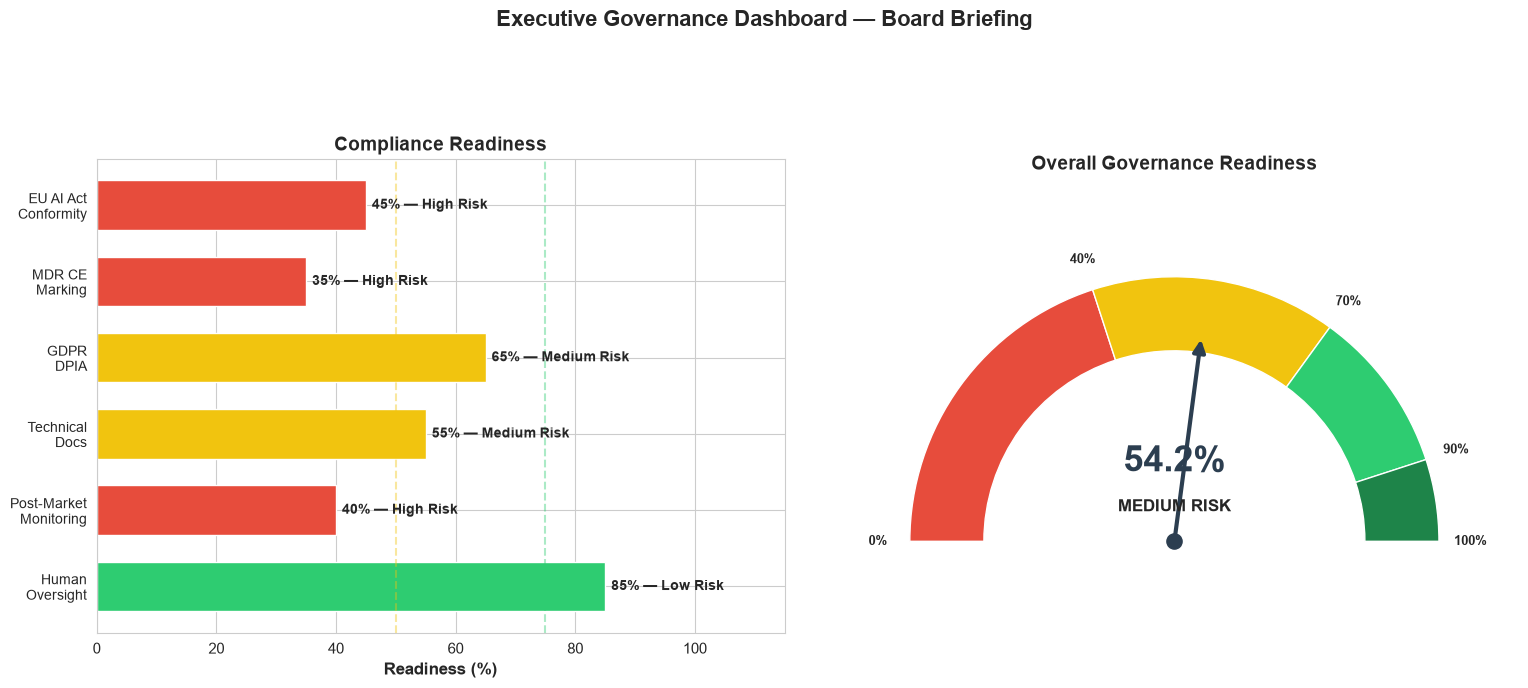

✅ Saved: results/executive_dashboard.png


In [20]:
# Step 8a: Create executive readiness dashboard

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- LEFT PANEL: Compliance Readiness Bars ---

# 🔧 TODO: Assign realistic readiness percentages for each area based on YOUR analysis.
# Think about what you found in Steps 2-7. Which areas are strong? Which are weak?
# Readiness scores are analyst estimates supported by findings from Steps 2–7.
# They represent implementation readiness, not formal legal compliance percentages.

readiness_basis = [
    {
        "area": "EU AI Act Conformity",
        "chart_label": "EU AI Act\nConformity",
        "score": 45,
        "evidence": (
            "Step 2 identified 1 Critical and 5 High compliance gaps, "
            "including accuracy, risk management, data governance, "
            "dataset representativeness, and robustness."
        )
    },
    {
        "area": "MDR CE Marking",
        "chart_label": "MDR CE\nMarking",
        "score": 35,
        "evidence": (
            "ClinicalCompanion has a working Class IIa classification, "
            "but the Notified Body conformity assessment and CE marking "
            "have not been completed."
        )
    },
    {
        "area": "GDPR DPIA",
        "chart_label": "GDPR\nDPIA",
        "score": 65,
        "evidence": (
            "A DPIA and de-identification controls exist, but the DPIA "
            "requires an update for foundation-model data flows and a "
            "Transfer Impact Assessment is still pending."
        )
    },
    {
        "area": "Technical Documentation",
        "chart_label": "Technical\nDocs",
        "score": 55,
        "evidence": (
            "The system specification, risk register, Model Card, and "
            "governance assessment exist, but the Annex IV package, "
            "logging evidence, and conformity documentation remain incomplete."
        )
    },
    {
        "area": "Post-Market Monitoring",
        "chart_label": "Post-Market\nMonitoring",
        "score": 40,
        "evidence": (
            "Step 7 defines 16 KPIs, an incident taxonomy, and response "
            "SLAs, but operational deployment and monitoring for automation "
            "bias, vendor changes, adversarial attacks, and cross-border "
            "transfers remain incomplete."
        )
    },
    {
        "area": "Human Oversight",
        "chart_label": "Human\nOversight",
        "score": 85,
        "evidence": (
            "Step 2 found physician review and override capability compliant. "
            "Remaining work includes final training materials and measurement "
            "of physician acceptance and override rates."
        )
    }
]

areas = [
    item["chart_label"]
    for item in readiness_basis
]

readiness = [
    item["score"]
    for item in readiness_basis
]

# Display the evidence used to support each readiness score
readiness_evidence_df = pd.DataFrame(
    readiness_basis
)[["area", "score", "evidence"]]

print("=" * 90)
print("EXECUTIVE READINESS SCORE BASIS")
print("=" * 90)

for _, row in readiness_evidence_df.iterrows():
    print(f"\n{row['area']}: {row['score']}%")
    print(f"Evidence: {row['evidence']}")

print(
    f"\nOverall readiness: "
    f"{np.mean(readiness):.1f}%"
)

# 🔧 TODO: Create horizontal bar chart with readiness percentages.
# Color-code: green (≥75%), yellow (50-74%), red (<50%).
# Add labels showing percentage and risk level to the right of each bar.

readiness_colors = [
    '#2ecc71' if value >= 75
    else '#f1c40f' if value >= 50
    else '#e74c3c'
    for value in readiness
]

risk_levels = [
    'Low Risk' if value >= 75
    else 'Medium Risk' if value >= 50
    else 'High Risk'
    for value in readiness
]

y_positions = np.arange(len(areas))

readiness_bars = ax1.barh(
    y_positions,
    readiness,
    color=readiness_colors,
    edgecolor='white',
    height=0.65
)

ax1.set_yticks(y_positions)
ax1.set_yticklabels(areas, fontsize=10)

for bar, value, risk_level in zip(
    readiness_bars,
    readiness,
    risk_levels
):
    ax1.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{value}% — {risk_level}',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

ax1.axvline(
    x=75,
    color='#2ecc71',
    linestyle='--',
    alpha=0.4
)

ax1.axvline(
    x=50,
    color='#f1c40f',
    linestyle='--',
    alpha=0.4
)

ax1.set_xlabel('Readiness (%)', fontsize=12, fontweight='bold')
ax1.set_title('Compliance Readiness', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 115)
ax1.invert_yaxis()

# --- RIGHT PANEL: Governance Readiness Gauge ---

# 🔧 TODO: Calculate overall governance readiness score.
# The arithmetic mean gives equal weight to the six readiness areas.
score = np.mean(readiness)

# 🔧 TODO: Create a semi-circular gauge visualization.
# Draw color bands: red (0-40%), yellow (40-70%), green (70-90%),
# dark green (90-100%).
# Add a needle pointing to the score.
# Display the score as large text below the gauge.
# Hint: A semi-circle goes from π (left) to 0 (right). Map the score
# to an angle within that range.

gauge_bands = [
    (0, 40, '#e74c3c'),
    (40, 70, '#f1c40f'),
    (70, 90, '#2ecc71'),
    (90, 100, '#1e8449')
]

for lower, upper, color in gauge_bands:
    theta_start = 180 - (upper * 1.8)
    theta_end = 180 - (lower * 1.8)

    band = mpatches.Wedge(
        center=(0, 0),
        r=1.0,
        theta1=theta_start,
        theta2=theta_end,
        width=0.28,
        facecolor=color,
        edgecolor='white'
    )

    ax2.add_patch(band)

needle_angle = np.pi * (1 - score / 100)

needle_x = 0.78 * np.cos(needle_angle)
needle_y = 0.78 * np.sin(needle_angle)

ax2.annotate(
    '',
    xy=(needle_x, needle_y),
    xytext=(0, 0),
    arrowprops={
        'arrowstyle': '-|>',
        'color': '#2c3e50',
        'linewidth': 3,
        'mutation_scale': 18
    }
)

ax2.scatter(
    0,
    0,
    s=120,
    color='#2c3e50',
    zorder=5
)

for value in [0, 40, 70, 90, 100]:
    angle = np.pi * (1 - value / 100)

    label_x = 1.12 * np.cos(angle)
    label_y = 1.12 * np.sin(angle)

    ax2.text(
        label_x,
        label_y,
        f'{value}%',
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

if score >= 70:
    overall_status = 'LOW RISK'
elif score >= 40:
    overall_status = 'MEDIUM RISK'
else:
    overall_status = 'HIGH RISK'

ax2.text(
    0,
    0.30,
    f'{score:.1f}%',
    ha='center',
    va='center',
    fontsize=26,
    fontweight='bold',
    color='#2c3e50'
)

ax2.text(
    0,
    0.13,
    overall_status,
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold'
)

ax2.set_xlim(-1.3, 1.3)
ax2.set_ylim(-0.2, 1.3)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title(
    'Overall Governance Readiness',
    fontsize=14,
    fontweight='bold',
    pad=20
)

# Save
plt.suptitle(
    'Executive Governance Dashboard — Board Briefing',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout(pad=3)

plt.savefig(
    RESULTS_DIR / 'executive_dashboard.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("✅ Saved: results/executive_dashboard.png")

---

## Deliverables Checklist

Before submitting, verify that both deliverables are complete.

### Notebook

- [x] **Step 1:** System specification exploration — key facts extracted
- [x] **Step 2:** EU AI Act classification — decision tree and compliance gap analysis
- [x] **Step 3:** Risk assessment — summary statistics and mitigation analysis
- [x] **Step 4:** Risk heatmap and mitigation comparison — saved to `results/`
- [x] **Step 5:** Vendor evaluation chart — saved to `results/`
- [x] **Step 6:** Model Card performance chart — saved to `results/`
- [x] **Step 7:** Monitoring dashboard with four panels — saved to `results/`
- [x] **Step 8:** Executive dashboard — saved to `results/`

### Workbook — `governance_workbook.xlsx`

- [x] **Sheet 1:** EU AI Act Classification — classification and compliance gap table
- [x] **Sheet 2:** Risk Register — all eight risks with scores and mitigations
- [x] **Sheet 3:** Vendor Evaluation — category scores and recommendation
- [x] **Sheet 4:** Model Card — complete Model Card content
- [x] **Sheet 5:** Monitoring & Incidents — KPI table and incident response plan
- [x] **Sheet 6:** Executive Summary — board-ready narrative

### Results folder

- [x] `risk_heatmap.png`
- [x] `risk_mitigation_comparison.png`
- [x] `vendor_evaluation_chart.png`
- [x] `model_card_performance.png`
- [x] `monitoring_dashboard.png`
- [x] `executive_dashboard.png`